# Local Explanations (STaR-Local) — Results Summary

**Approach B: Amended STaR-Local**
- Blind extraction: LLM extracts features FOR/AGAINST without knowing the label, predicts
- Wrong predictions downweighted via 2x2 matrix (not discarded)
- Features clustered (UMAP+HDBSCAN) -> dedup-first canonical selection -> binary scoring -> L1 logistic regression

In [39]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from pathlib import Path

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

REPO = Path('.').resolve().parent
OUT = REPO / 'outputs' / 'local_explanations'

## 1. Load Peer Review Results

In [40]:
# Load both runs
baseline_path = OUT / 'peer_review_star_local_llama33_v2' / 'results_star_local.json'
sweep_path = OUT / 'peer_review_sweep_best_trial11' / 'results_star_local.json'

results = {}
for name, path in [('Baseline (default config)', baseline_path), 
                    ('Sweep-best (Trial 11)', sweep_path)]:
    if path.exists():
        with open(path) as f:
            results[name] = json.load(f)
        print(f"{name}: loaded")
    else:
        print(f"{name}: NOT FOUND at {path}")

print(f"\nLoaded {len(results)} result files")

Baseline (default config): loaded
Sweep-best (Trial 11): loaded

Loaded 2 result files


## 2. Metrics Comparison Table

In [41]:
rows = []
for name, r in results.items():
    for split in ['train', 'eval', 'test']:
        m = r[split]
        rows.append({
            'Config': name,
            'Split': split,
            'AUC': m['roc_auc'],
            'PR-AUC': m['pr_auc'],
            'Accuracy': m['accuracy'],
            'F1': m['f1'],
            'N Features': r['n_active_features'],
        })

metrics_df = pd.DataFrame(rows)
metrics_df.style.format({
    'AUC': '{:.4f}', 'PR-AUC': '{:.4f}', 
    'Accuracy': '{:.4f}', 'F1': '{:.4f}'
}).set_caption('STaR-Local on Peer Review')

,Config,Split,AUC,PR-AUC,Accuracy,F1,N Features
0,Baseline (default config),train,0.5964,0.7511,0.5907,0.6797,14
1,Baseline (default config),eval,0.6003,0.7524,0.5993,0.6884,14
2,Baseline (default config),test,0.5892,0.7451,0.5870,0.6782,14
3,Sweep-best (Trial 11),train,0.6160,0.7690,0.6883,0.8154,9
4,Sweep-best (Trial 11),eval,0.6168,0.7737,0.6883,0.8154,9
5,Sweep-best (Trial 11),test,0.6141,0.7700,0.6883,0.8154,9


## 2b. Example Per-Document Extracted Features

These are the raw features the LLM extracts per document (Step 1). Each feature follows the `[content] — [evaluation]` format. The LLM lists features FOR and AGAINST acceptance, then predicts.

In [42]:
cache_path.exists()

True

In [43]:
labels_path.exists()

True

In [51]:
import sys, textwrap
sys.path.insert(0, str(REPO))
from IPython.display import HTML, display

cache_path = OUT / 'peer_review_star_local_llama33_v2' / 'explanation_cache' / 'star_local_v1.jsonl'
if cache_path.exists():
    examples = []
    with open(cache_path) as f:
        for i, line in enumerate(f):
            if i >= 300:
                break
            examples.append(json.loads(line.strip()))
    
    labels_path = REPO / 'datasets' / 'peer-review' / 'splits' / 'train.csv'
    if not labels_path.exists():
        labels_path = labels_path.with_suffix('.csv.gz')
    if labels_path.exists():
        labels_df = pd.read_csv(labels_path, usecols=['id', 'judgement', 'text'])
        label_map = dict(zip(labels_df['id'].astype(str), labels_df['judgement']))
        text_map = dict(zip(labels_df['id'].astype(str), labels_df['text']))
    else:
        label_map, text_map = {}, {}

    from methods.local_explanations.parsing import parse_star_local_output

    def render_feature(feat, color):
        parts = feat.split(' — ', 1)
        if len(parts) == 2:
            content, evaluation = parts
            return f'''<div style="padding:6px 10px;margin:4px 0;border-left:3px solid {color};
                        background:{color}10;border-radius:0 6px 6px 0;font-size:13px;">
                        <span style="color:#333;">{content}</span>
                        <span style="color:{color};font-weight:500;"> — {evaluation}</span></div>'''
        return f'''<div style="padding:6px 10px;margin:4px 0;border-left:3px solid {color};
                    background:{color}10;border-radius:0 6px 6px 0;font-size:13px;">{feat}</div>'''

    def render_example(doc_id, parsed, true_label, text, case_label, badge_color):
        text_short = str(text)[:400] + ('...' if len(str(text)) > 400 else '')
        
        for_html = ''.join(render_feature(f, '#2E7D32') for f in parsed.features_for[:5])
        against_html = ''.join(render_feature(f, '#C62828') for f in parsed.features_against[:5])
        
        true_word = {1: 'Accepted', 0: 'Rejected'}.get(true_label, '?')
        pred_word = 'Accepted' if parsed.prediction == 'positive' else 'Rejected'
        true_color = '#2E7D32' if true_label == 1 else '#C62828'
        pred_color = '#2E7D32' if parsed.prediction == 'positive' else '#C62828'
        conf = parsed.confidence or ''
        
        return f'''
        <div style="border:1px solid #ddd;border-radius:10px;padding:16px;margin:16px 0;
                    background:#fafafa;font-family:system-ui,-apple-system,sans-serif;max-width:900px;">
            <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:10px;">
                <code style="font-size:12px;color:#666;">{f"{doc_id.split('_')[0].title()} Paper"}</code>
                <span style="background:{badge_color};color:white;padding:3px 10px;border-radius:12px;
                      font-size:11px;font-weight:600;">{case_label}</span>
            </div>
            <div style="background:white;padding:12px;border-radius:6px;border:1px solid #eee;
                        margin-bottom:12px;font-size:13px;color:#444;line-height:1.5;">
                {text_short}
            </div>
            <div style="display:flex;gap:16px;">
                <div style="flex:1;">
                    <div style="font-weight:600;font-size:12px;color:#2E7D32;margin-bottom:6px;
                                text-transform:uppercase;letter-spacing:0.5px;">
                        Features FOR acceptance ({len(parsed.features_for)})
                    </div>
                    {for_html}
                </div>
                <div style="flex:1;">
                    <div style="font-weight:600;font-size:12px;color:#C62828;margin-bottom:6px;
                                text-transform:uppercase;letter-spacing:0.5px;">
                        Features AGAINST acceptance ({len(parsed.features_against)})
                    </div>
                    {against_html}
                </div>
            </div>
            <div style="margin-top:12px;padding-top:10px;border-top:1px solid #eee;display:flex;gap:20px;font-size:13px;">
                <span>LLM Prediction: <strong style="color:{pred_color};">{pred_word}</strong>
                      <span style="color:#999;">({conf})</span></span>
                <span>True Label: <strong style="color:{true_color};">{true_word}</strong></span>
            </div>
        </div>'''

    shown = {'correct_pos': False, 'correct_neg': False, 'incorrect': False}
    cards = []
    for ex in examples:
        doc_id = ex['id']
        parsed = parse_star_local_output(ex['response'], 'accepted', 'rejected')
        true_label = label_map.get(doc_id)
        if true_label is None or (not parsed.features_for and not parsed.features_against):
            continue
        
        pred_pos = parsed.prediction == 'positive'
        true_pos = true_label == 1
        
        if pred_pos == true_pos and true_pos and not shown['correct_pos']:
            case, label, color = 'correct_pos', 'CORRECT — Accepted', '#2E7D32'
        elif pred_pos == true_pos and not true_pos and not shown['correct_neg']:
            case, label, color = 'correct_neg', 'CORRECT — Rejected', '#1565C0'
        elif pred_pos != true_pos and not shown['incorrect']:
            case, label, color = 'incorrect', 'MISPREDICTED', '#E65100'
        else:
            continue
        
        shown[case] = True
        text = text_map.get(doc_id, '')
        cards.append(render_example(doc_id, parsed, true_label, text, label, color))
        
        if all(shown.values()):
            break
    
    display(HTML(''.join(cards)))
else:
    print(f"Cache not found at {cache_path}")

## 3. Test AUC: Baseline vs Sweep-Best

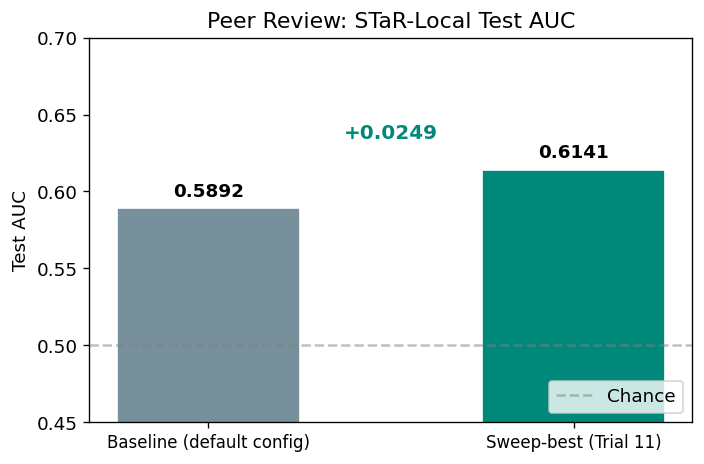

In [45]:
fig, ax = plt.subplots(figsize=(6, 4))

test_aucs = {name: r['test']['roc_auc'] for name, r in results.items()}
colors = ['#78909C', '#00897B']
bars = ax.bar(range(len(test_aucs)), list(test_aucs.values()), color=colors, width=0.5, edgecolor='white')
ax.set_xticks(range(len(test_aucs)))
ax.set_xticklabels(list(test_aucs.keys()), fontsize=10)
ax.set_ylabel('Test AUC')
ax.set_title('Peer Review: STaR-Local Test AUC')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax.set_ylim(0.45, 0.70)

for bar, val in zip(bars, test_aucs.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.4f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)

delta = list(test_aucs.values())[1] - list(test_aucs.values())[0]
ax.annotate(f'+{delta:.4f}', xy=(0.5, max(test_aucs.values()) + 0.02),
            fontsize=12, ha='center', color='#00897B', fontweight='bold')

ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 4. Feature Coefficients (Sweep-Best)

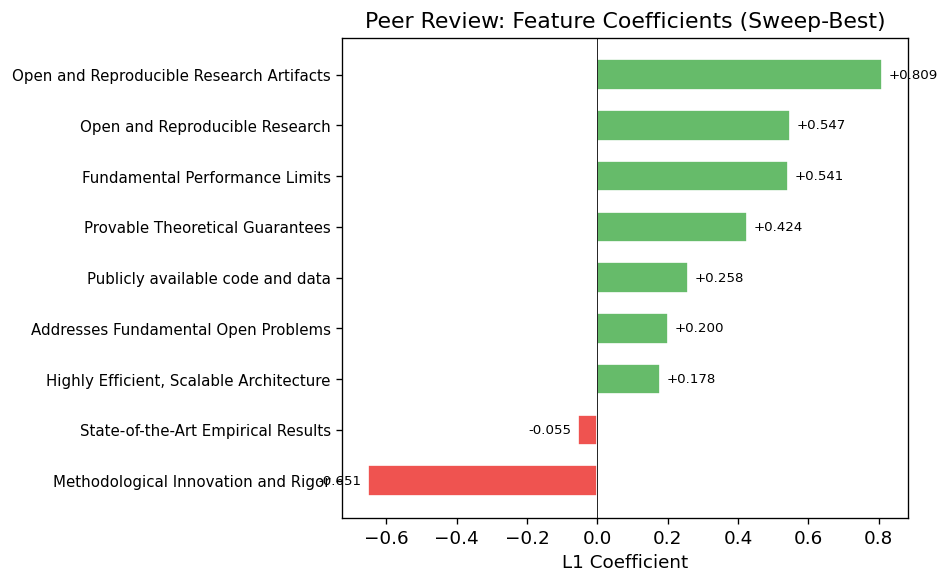

In [46]:
# Plot feature coefficients for the sweep-best config
best_key = 'Sweep-best (Trial 11)'
if best_key in results:
    feats = results[best_key]['active_features']
    names = [f['name'].replace('_', ' ') for f in feats]
    coefs = [f['coefficient'] for f in feats]
    
    # Sort by coefficient value
    order = np.argsort(coefs)
    names = [names[i] for i in order]
    coefs = [coefs[i] for i in order]
    
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['#EF5350' if c < 0 else '#66BB6A' for c in coefs]
    bars = ax.barh(range(len(names)), coefs, color=colors, edgecolor='white', height=0.6)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel('L1 Coefficient')
    ax.set_title('Peer Review: Feature Coefficients (Sweep-Best)')
    ax.axvline(0, color='black', linewidth=0.5)
    
    for bar, val in zip(bars, coefs):
        x = val + 0.02 if val > 0 else val - 0.02
        ax.text(x, bar.get_y() + bar.get_height()/2, f'{val:+.3f}', 
                va='center', ha='left' if val > 0 else 'right', fontsize=8)
    
    plt.tight_layout()
    plt.show()
else:
    print("Sweep-best results not found")

## 5. Sweep Hyperparameter Analysis

In [47]:
# Load Optuna study if available
sweep_dir = OUT / 'peer_review_optuna_sweep_v1'
study_db = sweep_dir / 'study.db'

if study_db.exists():
    import optuna
    study = optuna.load_study(study_name='local_explanations_peer_review',
                               storage=f'sqlite:///{study_db}')
    trials_df = study.trials_dataframe()
    trials_df = trials_df[trials_df['state'] == 'COMPLETE'].copy()
    print(f"Completed trials: {len(trials_df)}")
    print(f"Best eval AUC: {study.best_value:.4f} (trial {study.best_trial.number})")
    print(f"\nBest params:")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")
else:
    print(f"No study.db found at {study_db}")

Completed trials: 83
Best eval AUC: 0.6441 (trial 87)

Best params:
  wcw: 1.3209029983276113
  wcl: -0.04867773455920297
  wiw: -0.2820803032049464
  wil: 0.12113370666960704
  min_cluster_size: 200
  top_n_candidates: 50
  top_k_families: 20
  shrinkage_alpha: 0
  l1_C: 7.783597121003582
  class_weight: none


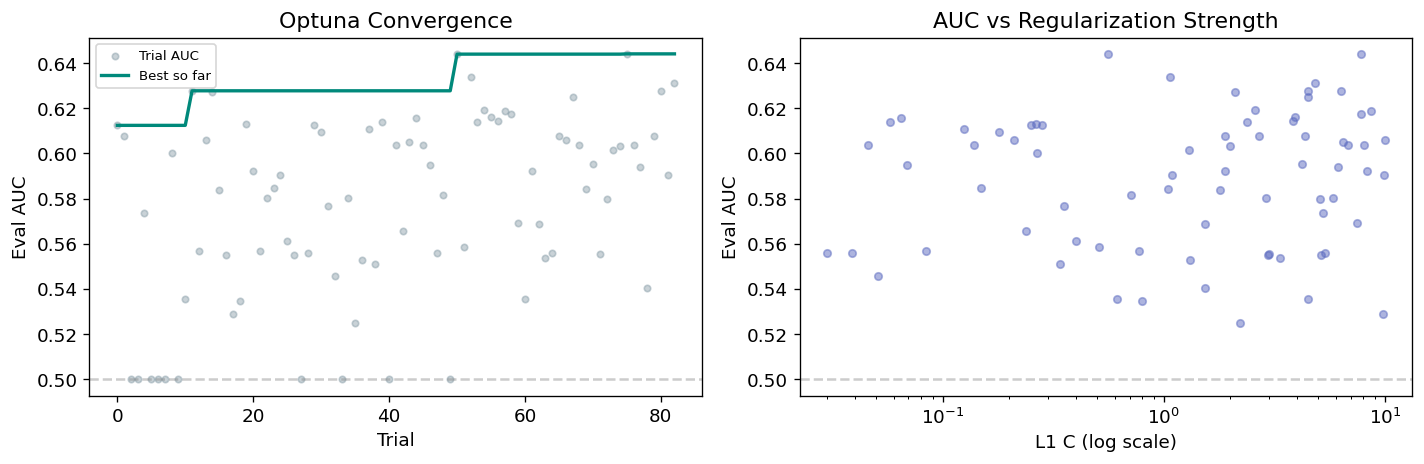

In [48]:
# Eval AUC over trials (convergence plot)
if study_db.exists() and len(trials_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Left: AUC over trials
    ax = axes[0]
    vals = trials_df.sort_values('number')['value'].values
    best_so_far = np.maximum.accumulate(vals)
    ax.scatter(range(len(vals)), vals, alpha=0.4, s=15, color='#78909C', label='Trial AUC')
    ax.plot(range(len(vals)), best_so_far, color='#00897B', linewidth=2, label='Best so far')
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4)
    ax.set_xlabel('Trial')
    ax.set_ylabel('Eval AUC')
    ax.set_title('Optuna Convergence')
    ax.legend(fontsize=8)
    
    # Right: key param importance (simple: AUC vs l1_C)
    ax = axes[1]
    valid = trials_df[trials_df['value'] > 0.5].copy()
    if 'params_l1_C' in valid.columns:
        ax.scatter(valid['params_l1_C'], valid['value'], alpha=0.5, s=20, color='#5C6BC0')
        ax.set_xscale('log')
        ax.set_xlabel('L1 C (log scale)')
        ax.set_ylabel('Eval AUC')
        ax.set_title('AUC vs Regularization Strength')
        ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()

## 6. Comparison with Other Methods

Placeholder — add dense RM, autometrics, metric tree results here when available.

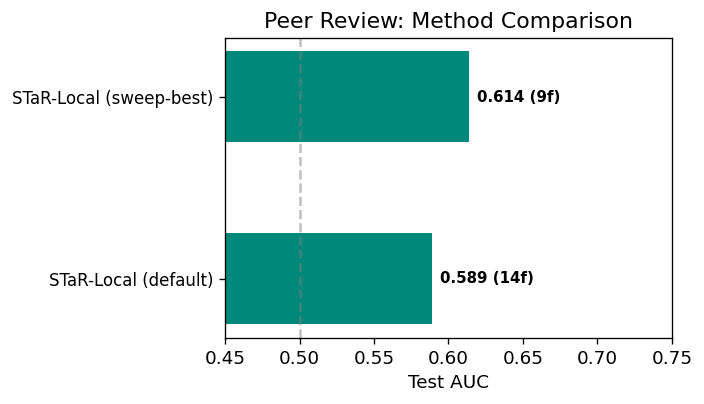

,Method,Test AUC,Features,Interpretable
0,STaR-Local (default),0.589,14,True
1,STaR-Local (sweep-best),0.614,9,True


In [49]:
# Cross-method comparison on peer-review (manual entries for now)
comparison = pd.DataFrame([
    {'Method': 'STaR-Local (default)', 'Test AUC': 0.589, 'Features': 14, 'Interpretable': True},
    {'Method': 'STaR-Local (sweep-best)', 'Test AUC': 0.614, 'Features': 9, 'Interpretable': True},
    # Add other methods as results become available:
    # {'Method': 'Dense RM (Llama-8B)', 'Test AUC': 0.656, 'Features': None, 'Interpretable': False},
    # {'Method': 'AutoMetrics Iterative', 'Test AUC': ..., 'Features': ..., 'Interpretable': True},
])

fig, ax = plt.subplots(figsize=(6, 3.5))
colors = ['#78909C' if not row['Interpretable'] else '#00897B' for _, row in comparison.iterrows()]
bars = ax.barh(range(len(comparison)), comparison['Test AUC'], color=colors, height=0.5)
ax.set_yticks(range(len(comparison)))
ax.set_yticklabels(comparison['Method'], fontsize=10)
ax.set_xlabel('Test AUC')
ax.set_title('Peer Review: Method Comparison')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlim(0.45, 0.75)

for bar, row in zip(bars, comparison.itertuples()):
    label = f'{row._2:.3f}'
    if row.Features:
        label += f' ({row.Features}f)'
    ax.text(row._2 + 0.005, bar.get_y() + bar.get_height()/2, label,
            va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()
comparison